<strong><span style="color:skyblue;font-size:40px"> Reinforcement Learning model for Quant analysis</strong><br>
- Data source from yahoo finance<br>
- train and test timer periods<br>
- Gymnasium for the model reward<br>

In [3]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import stable_baselines3 as sb3
import yfinance as yf
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
import os
import re
import gc
import json
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)
import glob
import torch
import random

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


<strong><span style="color:lightgreen;font-size:30px">Agent environment Build</strong><br>
- Uses OpenAI's gymnasium space<br>
<span style="color:red">- Reward function requires work!</strong>

In [ ]:
class StockTradingEnv(gym.Env):
    def __init__(self, data, reward_params=None, feature_cols=None, multi_ticker=False):
        self.full_data = data.copy()
        self.multi_ticker = multi_ticker

        # Choose one ticker or use full dataset
        if multi_ticker:
            self.data = pd.DataFrame()  # Empty for now, selected at reset
        else:
            self.data = self.full_data
            self.ticker = self.data['Ticker'].iloc[0]
            self.ticker_id = hash(self.ticker) % 1000

        self.current_step = 0
        self.portfolio_history = []
        self.cash = 10000
        self.holdings = 0
        self.action_history = []
        self.portfolio_value_history = []

        for col in self.full_data.columns:
            self.full_data[col] = pd.to_numeric(self.full_data[col], errors='coerce')

        self.action_space = spaces.Discrete(3)

        self.numeric_cols = feature_cols or self.full_data.select_dtypes(include=np.number).columns

        # Observation space defined after we get the actual state
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(self.numeric_cols) + 2,), dtype=np.float32)

        default_params = {
            "trade_reward": 2,
            "profit_scaler": 50,
            "volatility_penalty": 2,
            "allocation_penalty_scale": 5
        }
        self.reward_params = reward_params or default_params

        # Only reset if not multi-ticker — avoid out-of-bounds on empty `self.data`
        if not self.multi_ticker:
            self.reset()

    def _get_state(self):
        row = self.data.iloc[self.current_step][self.numeric_cols]
        # print("🧪 Row type:", type(row))
        # print("📐 Row shape:", row.shape)
        # print("🔢 Row preview:", row.head() if hasattr(row, "head") else row)
        cleaned = row.fillna(0).replace([np.inf, -np.inf], 0).astype(np.float32)  # 🧼 Explicit cast
        state = np.concatenate([cleaned.values, [self.cash, self.holdings]], axis=0)
        return state
    
    def step(self, action):
        self.action_history.append(int(action))
        price = self.data.iloc[self.current_step]['Close']
        portfolio_value = self.cash + self.holdings * price
        self.portfolio_value_history.append(portfolio_value)
        if action in [1, 2]:
            self.trade_log.append({
                "step": self.current_step,
                "action": int(action),
                "price": price,
                "cash": self.cash,
                "holdings": self.holdings
            })
        # Reward based on the current action
        reward = self.calculate_reward(action)
        # Advance to the next time step
        self.current_step += 1
        # Check if we’re done (end of the data)
        terminated = self.current_step >= len(self.data) - 1
        truncated = False  # Could be used for time limits, etc.
        # Get the next state observation
        observation = self._get_state()
        # Info dict — can be used for debugging, analytics, etc.
        info = {"portfolio_value": self.cash + self.holdings * self.data.iloc[self.current_step]['Close'],}
        return observation, reward, terminated, truncated, info

    def calculate_reward(self, action):
        """
        Balanced reward function:
        - Only rewards trade if it leads to profit (real or potential)
        - Encourages holding during calm periods
        - Penalizes unnecessary risk or allocation imbalance
        """

        price = self.data.iloc[self.current_step]['Close']
        prev_price = self.data.iloc[self.current_step - 1]['Close'] if self.current_step > 0 else price
        prev_portfolio_value = self.cash + self.holdings * price
        prev_allocation = (self.holdings * price) / (prev_portfolio_value + 1e-8)
        transaction_cost = price * 0.001
        reward = 0.0

        # Save portfolio value before the action
        prev_portfolio_value = self.cash + self.holdings * price

        # Simulate action
        if action == 1 and self.cash >= price + transaction_cost:
            self.holdings += 1
            self.cash -= price + transaction_cost
            self.last_buy_price = price  # ✅ new
        elif action == 2 and self.holdings > 0:
            self.holdings -= 1
            self.cash += price - transaction_cost
            if hasattr(self, 'last_buy_price'):
                profit = price - self.last_buy_price
                if profit > 0:
                    reward += profit * 2  # 🔧 amplify reward
                else:
                    reward += profit * 1.5  # soften punishment

        elif action == 2 and self.holdings > 0:
            # Sell
            self.holdings -= 1
            self.cash += price - transaction_cost

        # After-action portfolio
        new_portfolio_value = self.cash + self.holdings * price
        portfolio_change = (new_portfolio_value - prev_portfolio_value) / (prev_portfolio_value + 1e-8)

        # Reward is primarily driven by profit
        reward += self.reward_params["profit_scaler"] * portfolio_change

        # Encourage holding if price is stable (low volatility)
        price_change_pct = abs(price - prev_price) / (prev_price + 1e-8)
        if action == 0 and price_change_pct < 0.002:  # < 0.2% change
            reward += 0.1  # small bonus for sensible inactivity

        # Penalize if too much cash or too much stock (over-skew)
        total_value = self.cash + self.holdings * price
        allocation = (self.holdings * price) / (total_value + 1e-8)
        if prev_allocation < 0.05 and allocation >= 0.1:
            reward += 0.5  # ✅ Encourages entering the market
        elif allocation > 0.95 or allocation < 0.05:
            reward -= self.reward_params["allocation_penalty_scale"] * abs(allocation - 0.5)

        invalid_action_penalty = -1  # 🔧 tune this!

        if action == 1 and self.cash < price + transaction_cost:
            reward += invalid_action_penalty
        elif action == 2 and self.holdings <= 0:
            reward += invalid_action_penalty
        elif action == 0 and self.holdings == 0:
            reward += invalid_action_penalty * 0.5

        profit_change = (new_portfolio_value - prev_portfolio_value) / (prev_portfolio_value + 1e-8)
        reward += profit_change * self.reward_params["profit_scaler"]

        # Add volatility penalty if recent portfolio value has been erratic
        self.portfolio_history.append(new_portfolio_value)
        if len(self.portfolio_history) > 10:
            recent_vol = np.std(self.portfolio_history[-10:])
            reward -= self.reward_params["volatility_penalty"] * recent_vol
        if abs(reward) > 50 or self.current_step % 500 == 0:
            print(f"[Step {self.current_step}] Action: {action} | Reward: {reward:.2f} | Allocation: {allocation:.2f}")
        return float(np.clip(reward, -20, 20))

    def log_action_distribution(self):
        import collections
        counts = collections.Counter(self.action_history)
        total = sum(counts.values()) or 1  # Avoid divide-by-zero
        print("Action Distribution:")
        for action in range(3):
            label = ['Hold', 'Buy', 'Sell'][action]
            pct = counts[action] / total
            print(f"  Action {action} ({label}): {counts[action]} ({pct:.2%})")


    def reset(self, *, seed=None, options=None):
        self.action_history = []
        self.portfolio_value_history = []
        self.trade_log = []

        if self.multi_ticker:
            available = self.full_data['Ticker'].unique()
            self.current_ticker = np.random.choice(available)
            self.data = self.full_data[self.full_data['Ticker'] == self.current_ticker].reset_index(drop=True)
            print(f"🔁 New episode using ticker: {self.current_ticker}")

        if len(self.data) == 0:
            raise ValueError("Environment reset with empty data.")

        self.current_step = 0
        self.cash = 10000
        self.holdings = 0

        if seed is not None:
            np.random.seed(seed)

        return self._get_state(), {}

Financial moddeling functions

In [ ]:
def rolling_statistics(data, window):
    """
    Calculates rolling statistics given a series of data and window size.
    Returns: Rolling Max, Min, Standard deviation, Average
    Parameters:
        data: Pandas Series
        window: int, length of rolling window
    """
    rolling_max = data.rolling(window=window).max()
    rolling_min = data.rolling(window=window).min()
    rolling_std = data.rolling(window=window).std()
    rolling_average = data.rolling(window=window).mean()
    return rolling_max, rolling_min, rolling_std, rolling_average

def rsi (data,window):
    """
    calcualtes the RSI score (Relative Strength Index) for a given data series
    :paramaters
        data: pandas Series
        Window: int, length of rolling window
    """
    delta = data.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta > 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain/(avg_loss + 1e-10)  # Avoid division by zero
    rsi = 100 - (100 / (1+rs))
    return rsi

def macd(data, short_window, long_window, signal_window):
    """
    Moving Average Convergence Divergence (MACD) calculation.
    Meansures trend strength and direction.
    Paramenters:
        data: Pandas Series
        short_window: int, short-term moving average window - recomended = 12
        long_window: int, Long-term moving average window - recomended = 26
        signal_window: int, Signal line moving average window - recomended = 9
    Retuerns:
        MACD_line:Pandas Series
        Signal_line: Pandas Series
    """
    ema_short = data.ewm(span=short_window, adjust=False).mean()
    ema_long = data.ewm(span=long_window, adjust=False).mean()
    macd_line = ema_short - ema_long
    macd_signal = macd_line.ewm(span=signal_window, adjust=False).mean()
    return macd_line, macd_signal


<strong><span style="font-size:30px;color:lightpink">download stocks data from yfinance ready for analysis</strong><br>
| Ticker  | Company Name            |
|---------|------------------------|
| TSLA    | Tesla Inc              |
| NVDA    | NVIDIA Corporation     |
| PG      | Procter & Gamble Co    |
| BARC.L  | Barclays PLC           |
| EZJ.L   | EasyJet PLC            |
| BA.L    | BAE Systems PLC        |

In [ ]:
tickers = [ 
    'III.L', 'ADM.L', 'AAF.L', 'ALW.L', 'AAL.L', 'ANTO.L', 'AHT.L', 'ABF.L', 'AZN.L', 'AUTO.L',
    'AV.L', 'BAB.L', 'BA.L', 'BARC.L', 'BTRW.L', 'BEZ.L', 'BKG.L', 'BP.L', 'BATS.L', 'BT-A.L',
    'BNZL.L', 'CNA.L', 'CCEP.L', 'CCH.L', 'CPG.L', 'CTEC.L', 'CRDA.L', 'DCC.L', 'DGE.L', 'DPLM.L',
    'EDV.L', 'ENT.L', 'EZJ.L', 'EXPN.L', 'FCIT.L', 'FRES.L', 'GAW.L', 'GLEN.L', 'GSK.L', 'HLN.L',
    'HLMA.L', 'HIK.L', 'HSX.L', 'HWDN.L', 'HSBA.L', 'IHG.L', 'IMI.L', 'IMB.L', 'INF.L', 'ICG.L',
    'IAG.L', 'ITRK.L', 'JD.L', 'KGF.L', 'LAND.L', 'LGEN.L', 'LLOY.L', 'LMP.L', 'MNG.L', 'MKS.L',
    'MRO.L', 'MNDI.L', 'NG.L', 'NWG.L', 'NXT.L', 'PSON.L', 'PSH.L', 'PSN.L', 'PHNX.L', 'PCT.L',
    'PRU.L', 'RKT.L', 'REL.L', 'RTO.L', 'RMV.L', 'RIO.L', 'RR.L', 'SGE.L', 'SBRY.L', 'SDR.L',
    'SMT.L', 'SGRO.L', 'SVT.L', 'SHEL.L', 'SMIN.L', 'SN.L', 'SPX.L', 'SSE.L', 'STJ.L', 'STAN.L',
    'TW.L', 'TSCO.L', 'ULVR.L', 'UTG.L', 'UU.L', 'VOD.L', 'WEIR.L', 'WTB.L', 'WPP.L'
    ]

print("Downloading data stocks data...")
data = yf.download(tickers= tickers, start='2018-01-01', end='2024-12-31', group_by='ticker')
print("stocks data downloaded.")
# reshare the data to be multi idex table
data = data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index()
# convert to ordered by ticker then date
data = data.sort_values(by=['Ticker', 'Date'])
print(data.dtypes)

training_data = data[data['Date'] < '2022-01-01']
testing_data = data[data['Date'] >= '2022-01-01']

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  99 of 99 completed
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_35796/3154281929.py:18: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index()


stocks data downloaded.
Price
Date      datetime64[ns]
Ticker            object
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object


In [7]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
processed_data = []

for symbol in tickers:
    print(f"📈 Processing features for {symbol}...")
    
    # Extract and sort data for this symbol
    symbol_df = training_data[training_data['Ticker'] == symbol].copy()
    symbol_df = symbol_df.sort_values(by="Date")
    
    # Generate technical indicators
    for feature in features:
        rolling_max, rolling_min, rolling_std, rolling_avg = rolling_statistics(symbol_df[feature], window=21)
        symbol_df[f'{feature}_rolling_max_21'] = rolling_max
        symbol_df[f'{feature}_rolling_min_21'] = rolling_min
        symbol_df[f'{feature}_rolling_std_21'] = rolling_std
        symbol_df[f'{feature}_rolling_avg_21'] = rolling_avg
        
        symbol_df[f'{feature}_rsi'] = rsi(symbol_df[feature], window=14)
        macd_line, macd_signal = macd(symbol_df[feature], short_window=12, long_window=26, signal_window=9)
        symbol_df[f'{feature}_macd'] = macd_line
        symbol_df[f'{feature}_macd_signal'] = macd_signal

    # Keep only the features we need
    symbol_df = symbol_df[['Ticker', 'Date', 'Close', 'Volume', 'Close_rolling_max_21',
                           'Close_rolling_min_21', 'Close_rolling_std_21', 'Close_rolling_avg_21',
                           'Close_rsi', 'Close_macd', 'Close_macd_signal']].copy()

    processed_data.append(symbol_df)

# Combine all tickers' data
symbol_data = pd.concat(processed_data, axis=0)
symbol_data = symbol_data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

# (Optional) Save or preview
print("✅ Data ready for training:")
display(symbol_data.head())
print(symbol_data.columns)

# Save log
log_dir = "/Users/zacwells/Desktop/Reinforcement_Learning_stock_trading_env.csv"
os.makedirs(os.path.dirname(log_dir), exist_ok=True)
symbol_data.to_csv(log_dir, index=False)

📈 Processing features for III.L...
📈 Processing features for ADM.L...
📈 Processing features for AAF.L...
📈 Processing features for ALW.L...
📈 Processing features for AAL.L...
📈 Processing features for ANTO.L...
📈 Processing features for AHT.L...
📈 Processing features for ABF.L...
📈 Processing features for AZN.L...
📈 Processing features for AUTO.L...
📈 Processing features for AV.L...
📈 Processing features for BAB.L...
📈 Processing features for BA.L...
📈 Processing features for BARC.L...
📈 Processing features for BTRW.L...
📈 Processing features for BEZ.L...
📈 Processing features for BKG.L...
📈 Processing features for BP.L...
📈 Processing features for BATS.L...
📈 Processing features for BT-A.L...
📈 Processing features for BNZL.L...
📈 Processing features for CNA.L...
📈 Processing features for CCEP.L...
📈 Processing features for CCH.L...
📈 Processing features for CPG.L...
📈 Processing features for CTEC.L...
📈 Processing features for CRDA.L...
📈 Processing features for DCC.L...
📈 Processing 

Price,Ticker,Date,Close,Volume,Close_rolling_max_21,Close_rolling_min_21,Close_rolling_std_21,Close_rolling_avg_21,Close_rsi,Close_macd,Close_macd_signal
0,AAF.L,2019-06-28,67.741371,64367704.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
1,AAF.L,2019-07-01,70.938599,16286773.0,NaN,NaN,NaN,NaN,NaN,0.255049,0.051010
2,AAF.L,2019-07-02,71.937744,3565649.0,NaN,NaN,NaN,NaN,NaN,0.531672,0.147142
3,AAF.L,2019-07-03,72.037651,6511595.0,NaN,NaN,NaN,NaN,NaN,0.750310,0.267776
4,AAF.L,2019-07-04,72.337395,269558.0,NaN,NaN,NaN,NaN,NaN,0.936968,0.401614


Index(['Ticker', 'Date', 'Close', 'Volume', 'Close_rolling_max_21',
       'Close_rolling_min_21', 'Close_rolling_std_21', 'Close_rolling_avg_21',
       'Close_rsi', 'Close_macd', 'Close_macd_signal'],
      dtype='object', name='Price')


Vanilla PPO – Vanilla | Data shape: (98107, 11)
Skipping Vanilla_PPO_Vanilla at 100000 steps (already exists)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[Step 0] Action: 1 | Reward: -2.47 | Allocation: 0.01
[Step 63] Action: 2 | Reward: -52.86 | Allocation: 0.03
[Step 64] Action: 1 | Reward: -51.59 | Allocation: 0.04
[Step 65] Action: 1 | Reward: -53.05 | Allocation: 0.04
[Step 66] Action: 0 | Reward: -57.26 | Allocation: 0.04
[Step 67] Action: 1 | Reward: -56.81 | Allocation: 0.04
[Step 75] Action: 1 | Reward: -51.85 | Allocation: 0.08
[Step 76] Action: 2 | Reward: -59.81 | Allocation: 0.08
[Step 77] Action: 0 | Reward: -66.69 | Allocation: 0.08
[Step 78] Action: 2 | Reward: -72.44 | Allocation: 0.08
[Step 79] Action: 1 | Reward: -81.09 | Allocation: 0.08
[Step 80] Action: 1 | Reward: -79.82 | Allocation: 0.09
[Step 81] Action: 0 | Reward: -66.08 | Allocation: 0.08
[Step 82] Action: 1 | Reward: -51.71 | Allocation: 0.09
[Step 85] Action: 2 | Reward: -50.44 | Allocation: 0.09
[Step 86] Action: 1 | Reward: -75.48 | Allocation: 0.09
[Step 87] Action: 0 | Reward: -89.27 | Allocation: 0.09
[Step 88] Action: 1 | Reward: -96.85 | Allocation:

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_35796/2830999054.py:131: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_35796/2830999054.py:176: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  growth_plot.savefig(growth_plot_path)


NameError: name 'result' is not defined

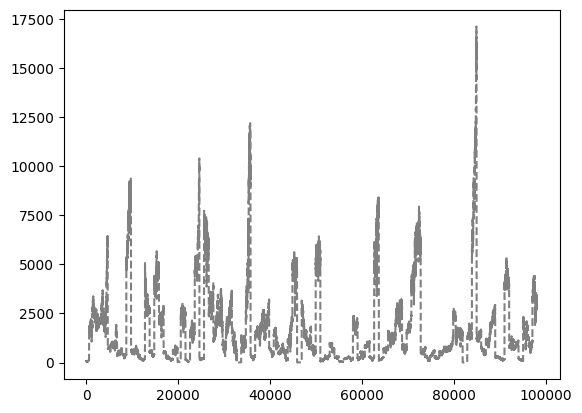

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO, A2C
from stable_baselines3.common.callbacks import CheckpointCallback

replace_models = False
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

# --- Reward Sweeps ---
reward_sweeps = [
    {"name": "Vanilla", "reward_params": {"trade_reward": 0, "profit_scaler": 30, "volatility_penalty": 0, "allocation_penalty_scale": 0}},
    # {"name": "Mild", "reward_params": {"trade_reward": 2, "profit_scaler": 30, "volatility_penalty": 1, "allocation_penalty_scale": 3}},
    # {"name": "Balanced", "reward_params": {"trade_reward": 5, "profit_scaler": 50, "volatility_penalty": 2, "allocation_penalty_scale": 5}},
    # {"name": "Spicy", "reward_params": {"trade_reward": 8, "profit_scaler": 80, "volatility_penalty": 3, "allocation_penalty_scale": 6}},
    # {"name": "HighStakes", "reward_params": {"trade_reward": 10, "profit_scaler": 100, "volatility_penalty": 0.5, "allocation_penalty_scale": 2}},
    # {"name": "Zen", "reward_params": {"trade_reward": 1, "profit_scaler": 40, "volatility_penalty": 4, "allocation_penalty_scale": 6}}
]

# --- Model Configurations ---
model_configs = [
    {"name": "Vanilla PPO", "kwargs": {}},
    # {"name": "Aggressive 1", "kwargs": {"ent_coef": 0.5, "vf_coef": 0.1, "learning_rate": 0.0005, "gamma": 0.95, "gae_lambda": 0.8, "clip_range": 0.3, "n_steps": 512, "batch_size": 128, "n_epochs": 5}},
    # {"name": "Aggressive 2", "kwargs": {"ent_coef": 0.3, "vf_coef": 0.05, "learning_rate": 0.001, "gamma": 0.9, "gae_lambda": 0.7, "clip_range": 0.4, "n_steps": 256, "batch_size": 64, "n_epochs": 10}},
    # {"name": "Curious Mind", "kwargs": {"ent_coef": 0.1, "vf_coef": 0.5}},
    # {"name": "Conservative 1", "kwargs": {"ent_coef": 0.005, "vf_coef": 0.9, "learning_rate": 0.0001, "gamma": 0.99, "gae_lambda": 0.95, "clip_range": 0.1, "n_steps": 2048, "batch_size": 256, "n_epochs": 4}},
    # {"name": "Conservative 2", "kwargs": {"ent_coef": 0.001, "vf_coef": 1.0, "learning_rate": 0.00005, "gamma": 0.995, "gae_lambda": 0.98, "clip_range": 0.05, "n_steps": 4096, "batch_size": 512, "n_epochs": 3}},
    # {"name": "Explorer Balanced", "kwargs": {"ent_coef": 0.15, "vf_coef": 0.3, "learning_rate": 0.0003, "gamma": 0.97, "gae_lambda": 0.85, "clip_range": 0.2, "n_steps": 1024, "batch_size": 128, "n_epochs": 6}},
    # {"name": "Fast Learner", "kwargs": {"ent_coef": 0.05, "vf_coef": 0.3, "learning_rate": 0.0015, "gamma": 0.98, "gae_lambda": 0.92, "clip_range": 0.2, "n_steps": 1024, "batch_size": 64, "n_epochs": 4}},
    # {"name": "YOLO Trader", "kwargs": {"ent_coef": 0.5, "vf_coef": 0.05, "learning_rate": 0.002, "gamma": 0.9, "gae_lambda": 0.7, "clip_range": 0.5, "n_steps": 128, "batch_size": 32, "n_epochs": 10}},
    # {"name": "Adaptive Balanced", "kwargs": {"ent_coef": 0.07, "vf_coef": 0.6, "learning_rate": 0.0003, "gamma": 0.985, "gae_lambda": 0.92, "clip_range": 0.15, "n_steps": 2048, "batch_size": 128, "n_epochs": 5}}
]

checkpoints = [100_000]
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

def make_json_safe(obj):
    if isinstance(obj, np.ndarray): return obj.tolist()
    if isinstance(obj, (np.integer, np.int32, np.int64)): return int(obj)
    if isinstance(obj, (np.floating, np.float32, np.float64)): return float(obj)
    if isinstance(obj, set): return list(obj)
    raise TypeError(f"Not JSON serializable: {type(obj)}")

def train_with_checkpoints(config, env_class, train_data, reward_params):
    model_name = f"{config['name'].replace(' ', '_')}_{reward_params['name']}"
    results = []
    env = env_class(train_data.copy(), reward_params=reward_params["reward_params"])
    model = PPO("MlpPolicy", env, verbose=0, **config["kwargs"], device=device)

    for step in checkpoints:
        model_path = f"{checkpoint_dir}/{model_name}_{step}_steps.zip"
        if os.path.exists(model_path) and not replace_models:
            print(f"Skipping {model_name} at {step} steps (already exists)")
            results.append((step, model_path))
            continue

        print(f"Training {model_name} to {step} steps...")
        model.learn(total_timesteps=step - model.num_timesteps)
        model.save(model_path)
        results.append((step, model_path))
        gc.collect()

    del model, env
    gc.collect()
    return results

def make_json_safe(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    elif isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    elif isinstance(obj, (set,)):
        return list(obj)
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

def load_model(path):
    return PPO.load(path)

# --- Helper: Evaluate a model checkpoint ---
def evaluate_checkpoint(model_path, data, env_class, model_name, sweep_name):
    env = env_class(data)
    model = load_model(model_path)

    obs, _ = env.reset()
    done = False

    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, truncated, info = env.step(action)

    # 🧠 Extract step count from filename
    match = re.search(r"_(\d+)_steps", model_path)
    step_count = int(match.group(1)) if match else 0

    result = {
    "name": f"{model_name} – {sweep_name}",
    "step": step_count,
    "final_portfolio_value": info["portfolio_value"],
    "actions": env.action_history,
    "portfolio": env.portfolio_value_history,
    "prices": env.data['Close'].iloc[:len(env.action_history)].values,
    "dates": env.data.index[:len(env.portfolio_value_history)].tolist(),
    "trade_log": env.trade_log
}

    return result, env

def plot_portfolio_growth(result):
    plt.figure(figsize=(15, 6))

    # Map portfolio history to dates
    dates = result.get("dates")
    if dates is None:
        # Try infer from prices length if not saved
        print("⚠️ No dates found in result. X-axis will remain as step index.")
        x = list(range(len(result["portfolio"])))
    else:
        x = dates[:len(result["dates"])]

    plt.plot(x, result["portfolio"], label="Portfolio Value (£)", color="blue", linewidth=2)
    plt.title(f"📈 Portfolio Growth {result['name']}")
    plt.xlabel("Date" if dates is not None else "Step")
    plt.ylabel("Portfolio Value (£)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    return plt

def plot_actions(result):
    plt.figure(figsize=(15, 6))
    plt.plot(result["prices"], label="Price", color="black")

    # Only show actual trades from trade_log
    for trade in result["trade_log"]:
        step = trade["step"]
        action = trade["action"]
        price = trade["price"]
        if action == 1:
            plt.scatter(step, price, marker='^', color='green', label='Buy' if step == result["trade_log"][0]["step"] else "", s=100)
        elif action == 2:
            plt.scatter(step, price, marker='v', color='red', label='Sell' if step == result["trade_log"][0]["step"] else "", s=100)

    plt.title(f"Trading Actions – {result['name']}")
    plt.xlabel("Step")
    plt.ylabel("Price (£)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Main Routine ---
all_results = []

for sweep in reward_sweeps:
    for config in model_configs:
        print(f"{config['name']} – {sweep['name']} | Data shape: {symbol_data.shape}")
        assert len(symbol_data) > 0, "⚠️ symbol_data is empty!"
        checkpoints_info = train_with_checkpoints(config, StockTradingEnv, symbol_data, sweep)

        for step, model_path in checkpoints_info:
            result, env = evaluate_checkpoint(
                model_path, symbol_data, StockTradingEnv,
                config["name"], sweep["name"]
            )
            env.log_action_distribution()
            print(f"Final portfolio value: {result['final_portfolio_value']:.2f} £")
            # ✅ Save result to disk (JSON)
            result_file = f"{results_dir}/{result['name'].replace(' ', '_')}_{result['step']}_result.json"
            growth_plot = plot_portfolio_growth(result)
            growth_plot_path = f"{results_dir}/{result['name'].replace(' ', '_')}_{result['step']}_growth.png"
            growth_plot.savefig(growth_plot_path)
            growth_plot.close()
            print(f"📊 Portfolio growth plot saved to {growth_plot_path}")

            starting_price = result["prices"][0]
            benchmark = [starting_price * (i / starting_price) for i in result["prices"]]

            plt.plot(benchmark, label="Buy & Hold", linestyle="--", color="gray")

            # ✅ Save plot to disk instead of displaying
            print("creating plot for", result['name'])
            # ✅ Clean up memory
            del result, env
            gc.collect()

print(f"All results saved to {result}")

<strong><span style="font-size:40px;color:orange">Model Testing on other datasets</strong><br>

In [44]:
print("🔍 Building index-style FTSE 100 test dataset...")

# Build index-like test data
index_like_test_data = []

for ticker in testing_data['Ticker'].unique():
    ticker_df = testing_data[testing_data['Ticker'] == ticker].copy()

    for feature in features:
        rolling_max, rolling_min, rolling_std, rolling_avg = rolling_statistics(ticker_df[feature], window=21)
        ticker_df[feature + '_rolling_max_21'] = rolling_max
        ticker_df[feature + '_rolling_min_21'] = rolling_min
        ticker_df[feature + '_rolling_std_21'] = rolling_std
        ticker_df[feature + '_rolling_avg_21'] = rolling_avg

        ticker_df[feature + '_rsi'] = rsi(ticker_df[feature], window=14)
        macd_line, macd_signal = macd(ticker_df[feature], short_window=12, long_window=26, signal_window=9)
        ticker_df[feature + '_macd'] = macd_line
        ticker_df[feature + '_macd_signal'] = macd_signal

    index_like_test_data.append(ticker_df)

# ✅ Combine all tickers into one DataFrame
index_fund_test_data = pd.concat(index_like_test_data)
index_fund_test_data = index_fund_test_data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

# ✅ Final features subset
index_fund_test_data = index_fund_test_data[[
    'Date', 'Ticker', 'Close', 'Volume',
    'Close_rolling_max_21', 'Close_rolling_min_21',
    'Close_rolling_std_21', 'Close_rolling_avg_21',
    'Close_rsi', 'Close_macd', 'Close_macd_signal'
]].copy()

print("✅ Index-style test dataset ready.")
print(index_fund_test_data.head())

# ✅ Now fix your loop — treat df as a DataFrame, not a dictionary!
# Convert the single DataFrame into a dict of DataFrames per ticker
index_fund_test_data_dict = {
    ticker: group.reset_index(drop=True)
    for ticker, group in index_fund_test_data.groupby('Ticker')
}

# ✅ Clean column names and ensure 'Ticker' exists
for name, df in index_fund_test_data_dict.items():
    df.columns.name = None  # Remove column name if it exists
    if 'Ticker' not in df.columns:
        df['Ticker'] = name
    index_fund_test_data_dict[name] = df  # update

🔍 Building index-style FTSE 100 test dataset...
✅ Index-style test dataset ready.
Price       Date Ticker       Close     Volume  Close_rolling_max_21  \
0     2022-01-04  AAF.L  141.043457  3719444.0                   NaN   
1     2022-01-05  AAF.L  140.843521  2336920.0                   NaN   
2     2022-01-06  AAF.L  136.945099  1091544.0                   NaN   
3     2022-01-07  AAF.L  138.844330  1299995.0                   NaN   
4     2022-01-10  AAF.L  134.546066  1773000.0                   NaN   

Price  Close_rolling_min_21  Close_rolling_std_21  Close_rolling_avg_21  \
0                       NaN                   NaN                   NaN   
1                       NaN                   NaN                   NaN   
2                       NaN                   NaN                   NaN   
3                       NaN                   NaN                   NaN   
4                       NaN                   NaN                   NaN   

Price  Close_rsi  Close_macd  Clos

index fund cols Index(['Date', 'Ticker', 'Close', 'Volume', 'Close_rolling_max_21',
       'Close_rolling_min_21', 'Close_rolling_std_21', 'Close_rolling_avg_21',
       'Close_rsi', 'Close_macd', 'Close_macd_signal'],
      dtype='object', name='Price')
['./checkpoints/Vanilla_PPO_Vanilla_100000_steps.zip']
Testing model: ./checkpoints/Vanilla_PPO_Vanilla_100000_steps.zip
 → Test set: IndexFund, rows: 74504
[Step 0] Action: 0 | Reward: -0.40 | Allocation: 0.00
[Step 500] Action: 0 | Reward: 0.00 | Allocation: 0.12
[Step 754] Action: 2 | Reward: 5848.47 | Allocation: 0.94
[Step 755] Action: 2 | Reward: 6016.21 | Allocation: 0.92
[Step 758] Action: 2 | Reward: 6133.92 | Allocation: 0.90
[Step 765] Action: 2 | Reward: 300.16 | Allocation: 0.88
[Step 778] Action: 2 | Reward: 131.44 | Allocation: 0.97
[Step 780] Action: 2 | Reward: 396.29 | Allocation: 0.95
[Step 792] Action: 2 | Reward: 305.07 | Allocation: 0.95
[Step 797] Action: 2 | Reward: -187.60 | Allocation: 0.95
[Step 800] Action: 

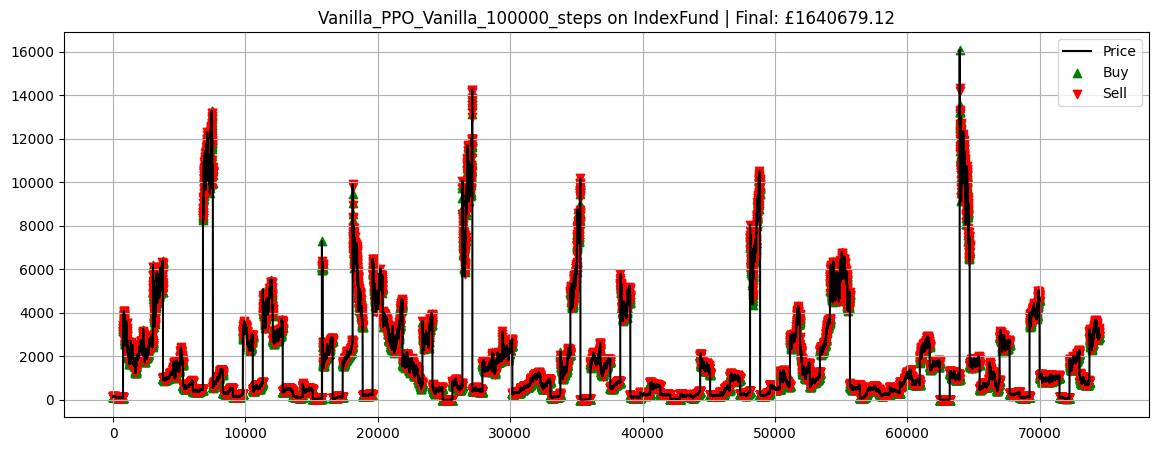

✅ Total results: 1


In [47]:
features_used_druing_training = ['Ticker', 'Date', 'Close', 'Volume', 'Close_rolling_max_21',
                           'Close_rolling_min_21', 'Close_rolling_std_21', 'Close_rolling_avg_21',
                           'Close_rsi', 'Close_macd', 'Close_macd_signal']

# Load model
def load_model(path):
    return PPO.load(path)

# Evaluate on test data
def evaluate_on_test(model_path, test_data, env_class, reward_params):
    model = load_model(model_path)
    env = env_class(test_data.copy(), reward_params=reward_params["reward_params"])  # ✅ FIXED HERE
    obs, _ = env.reset()
    done = False
    assert obs.shape == model.observation_space.shape, \
        f"Shape mismatch: obs {obs.shape}, model expects {model.observation_space.shape}"
    while not done:
        action, _ = model.predict(obs)
        obs, reward, done, truncated, info = env.step(action)
    print("📦 Observation shape at reset:", obs.shape)
    print("🤖 Model expects:", model.observation_space.shape)
    result = {
        "final_value": info["portfolio_value"],
        "actions": env.action_history,
        "portfolio": env.portfolio_value_history,
        "prices": env.data['Close'].iloc[:len(env.action_history)].values,
        "name": os.path.basename(model_path).replace(".zip", "")
    }
    return result

# Plotting
def plot_test_result(result, test_label):
    actions = np.array(result["actions"])
    buy_idx = np.where(actions == 1)[0]
    sell_idx = np.where(actions == 2)[0]

    plt.figure(figsize=(14, 5))
    plt.plot(result["prices"], label="Price", color="black")
    plt.scatter(buy_idx, result["prices"][buy_idx], color="green", label="Buy", marker="^")
    plt.scatter(sell_idx, result["prices"][sell_idx], color="red", label="Sell", marker="v")
    plt.title(f"{result['name']} on {test_label} | Final: £{result['final_value']:.2f}")
    plt.legend()
    plt.grid(True)
    plt.show()

# Summary
def print_summary(result):
    actions = np.array(result["actions"])
    buys = np.sum(actions == 1)
    sells = np.sum(actions == 2)
    holds = np.sum(actions == 0)
    print(f"🧾 {result['name']} | £{result['final_value']:.2f}")
    print(f"  🟩 Buys: {buys} | 🟥 Sells: {sells} | ⬜️ Holds: {holds}")
    print(f"  Trades total: {buys + sells}")
    print(f"  Final allocation: {(actions == 1).sum() / len(actions):.1%} buy freq")
    print("-" * 50)

# --- Run all tests
def run_test_suite(model_paths, test_datasets, env_class, reward_params):
    all_results = []
    for model_path in model_paths:
        print(f"Testing model: {model_path}")
        for test_name, df in test_datasets.items():
            print(f" → Test set: {test_name}, rows: {len(df)}")

            result = evaluate_on_test(model_path, df, env_class, reward_params)
            if result is None:
                print(" ⚠️  No result returned!")
                continue

            print_summary(result)
            fig = plot_test_result(result, test_name)
            all_results.append({
                "model_path": model_path,
                "test_name": test_name,
                "result": result,
                "figure": fig
            })

    print(f"✅ Total results: {len(all_results)}")
    return all_results

# Models to test
checkpoint_dir = "./checkpoints"
model_paths = sorted(glob.glob(os.path.join(checkpoint_dir, "*100000_steps.zip")))
print(f"index fund cols {index_fund_test_data.keys()}")
print(model_paths)
# Run the suite with the reward config you trained on
test_result = run_test_suite(model_paths, {"IndexFund": index_fund_test_data}, StockTradingEnv, reward_sweeps[0])